In [1]:
# Variability in Samples: Population vs. Two Samples
# -------------------------------------------------
# Requirements: numpy, matplotlib
# This script generates a skewed-ish population (mixture of normals),
# draws two samples (small n and larger n), and plots histograms with
# their sample means and standard deviations to illustrate variability.

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --------------------------
# 1) CONFIG
# --------------------------
np.random.seed(42)     # reproducible
N_POP = 2000        # population size
SAMPLE_A_N = 200        # small sample
SAMPLE_B_N = 1000       # larger sample
POP_BINS = 40
A_BINS = 12
B_BINS = 20
OUTFILE = "variability_population_samples.png"

In [3]:
# --------------------------
# 2) CREATE A POPULATION
#    (mixture distribution to induce asymmetry/heavy tail)
# --------------------------
pop_part1 = np.random.normal(loc=0.0, scale=1.0, size=int(N_POP * 0.75))
pop_part2 = np.random.normal(loc=3.0, scale=1.5, size=int(N_POP * 0.25))
population = np.concatenate([pop_part1, pop_part2])

pop_mean = np.mean(population)
pop_std = np.std(population, ddof=0)  # population SD

In [4]:
# --------------------------
# 3) DRAW TWO SAMPLES
# --------------------------
sample_a = np.random.choice(population, size=SAMPLE_A_N, replace=False)
sample_b = np.random.choice(population, size=SAMPLE_B_N, replace=False)

a_mean = np.mean(sample_a)
a_std = np.std(sample_a, ddof=1)  # sample SD
b_mean = np.mean(sample_b)
b_std = np.std(sample_b, ddof=1)

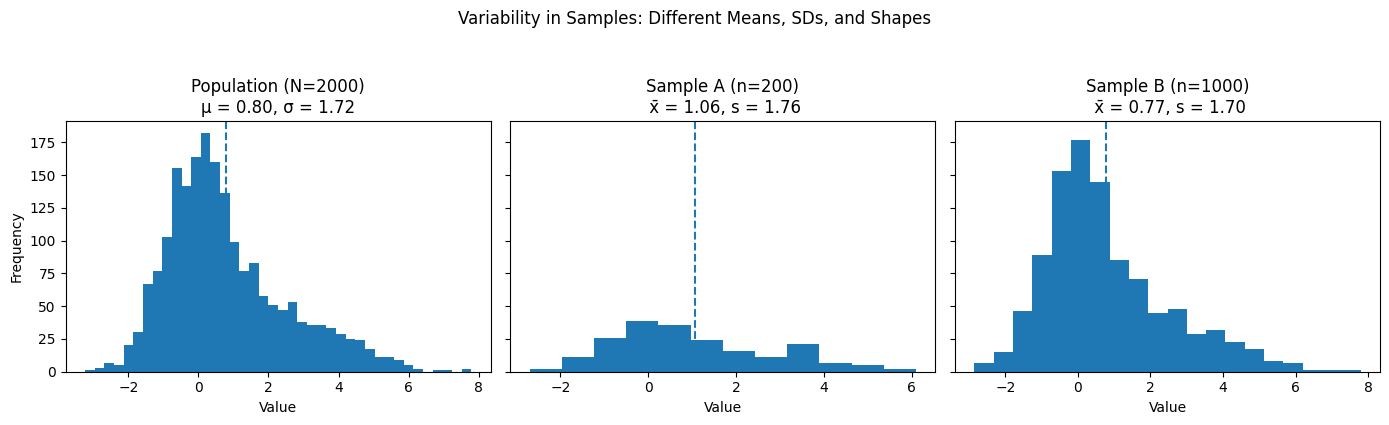

Saved figure to: variability_population_samples.png


In [5]:
# --------------------------
# 4) PLOT
# --------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

# Population
axes[0].hist(population, bins=POP_BINS)
axes[0].axvline(pop_mean, linestyle='--')
axes[0].set_title(f"Population (N={N_POP})\nμ = {pop_mean:.2f}, σ = {pop_std:.2f}")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")

# Sample A
axes[1].hist(sample_a, bins=A_BINS)
axes[1].axvline(a_mean, linestyle='--')
axes[1].set_title(f"Sample A (n={SAMPLE_A_N})\n x̄ = {a_mean:.2f}, s = {a_std:.2f}")
axes[1].set_xlabel("Value")

# Sample B
axes[2].hist(sample_b, bins=B_BINS)
axes[2].axvline(b_mean, linestyle='--')
axes[2].set_title(f"Sample B (n={SAMPLE_B_N})\n x̄ = {b_mean:.2f}, s = {b_std:.2f}")
axes[2].set_xlabel("Value")

plt.suptitle("Variability in Samples: Different Means, SDs, and Shapes", y=1.05, fontsize=12)
plt.tight_layout()
plt.savefig(OUTFILE, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {OUTFILE}")